In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [3]:
from urllib.request import urlretrieve
urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x2ab87241bd0>)

In [4]:
import pandas as pd
medical_df=pd.read_csv('medical.csv')

In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 8)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

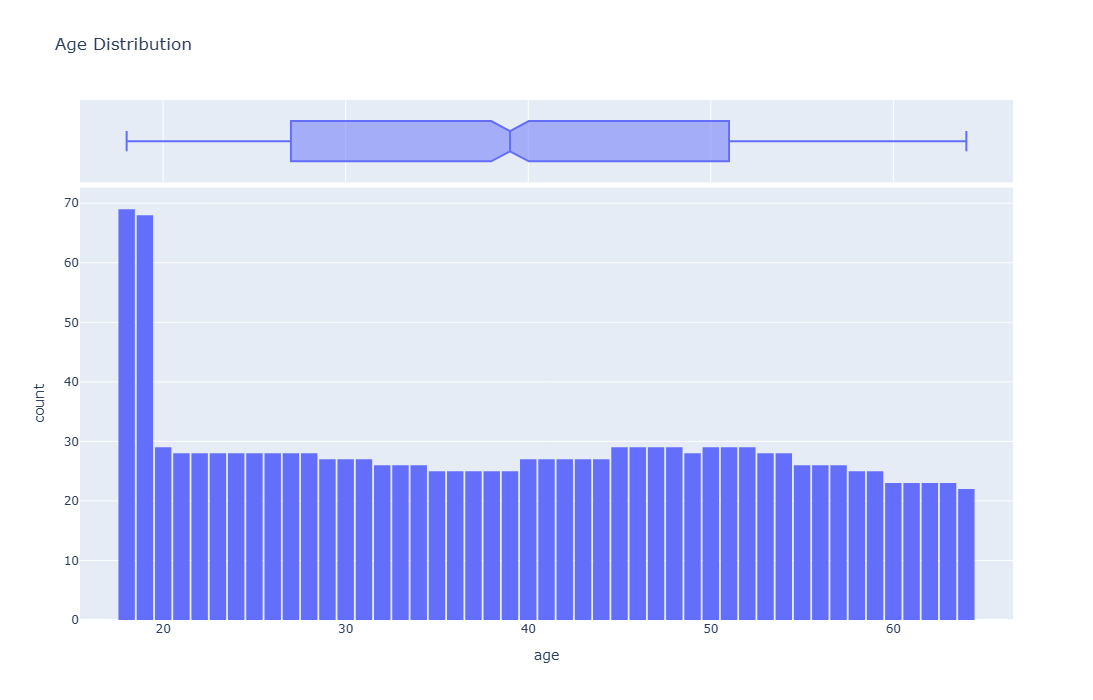

In [12]:
fig=px.histogram(medical_df,x='age',marginal="box",nbins=47,title="Age Distribution")
fig.update_layout(bargap=0.1,
                 height=700)
fig.show()

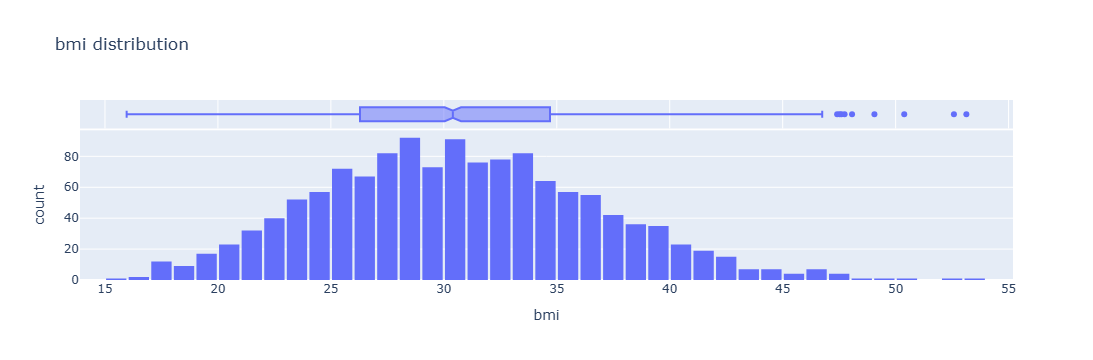

In [16]:
bmi_hist=px.histogram(medical_df,x='bmi',marginal='box', title="bmi distribution")
bmi_hist.update_layout(bargap=0.1)
bmi_hist.show()

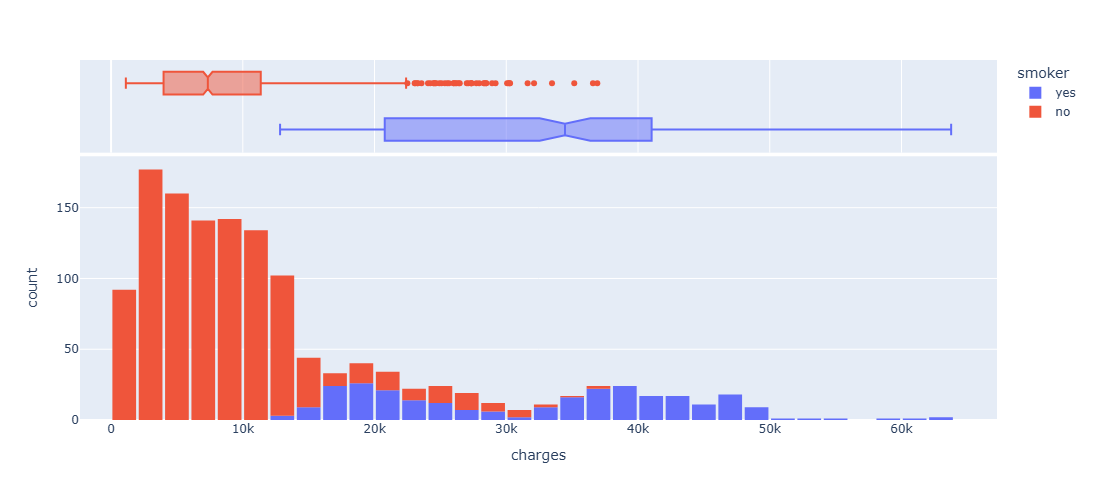

In [18]:
annual_charges_hist=px.histogram(medical_df,x='charges',color='smoker',marginal='box')
annual_charges_hist.update_layout(bargap=0.1,height=500)
annual_charges_hist.show()

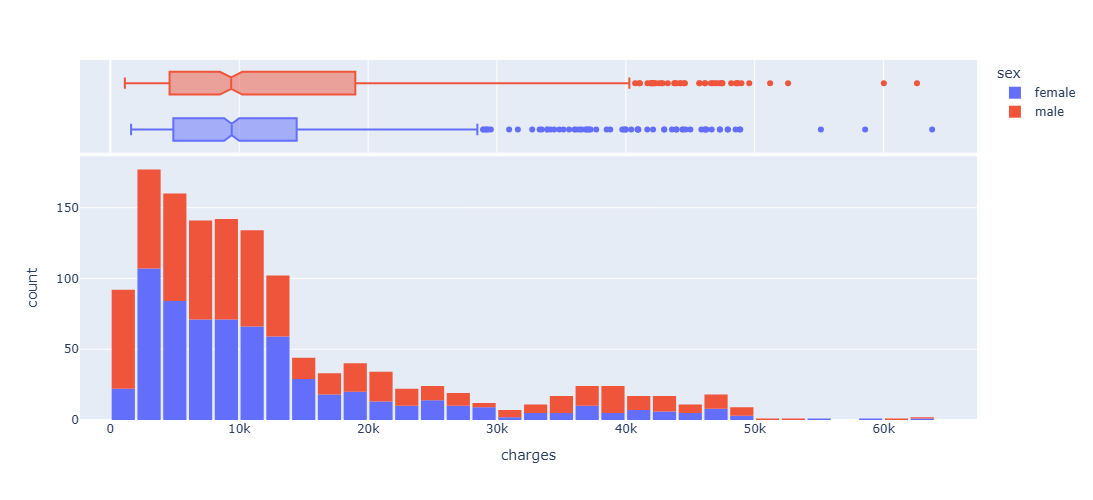

In [20]:
sex_hist=px.histogram(medical_df,x='charges',color='sex',marginal='box')
sex_hist.update_layout(bargap=0.1,height=500)
sex_hist.show()

### Age and Charges


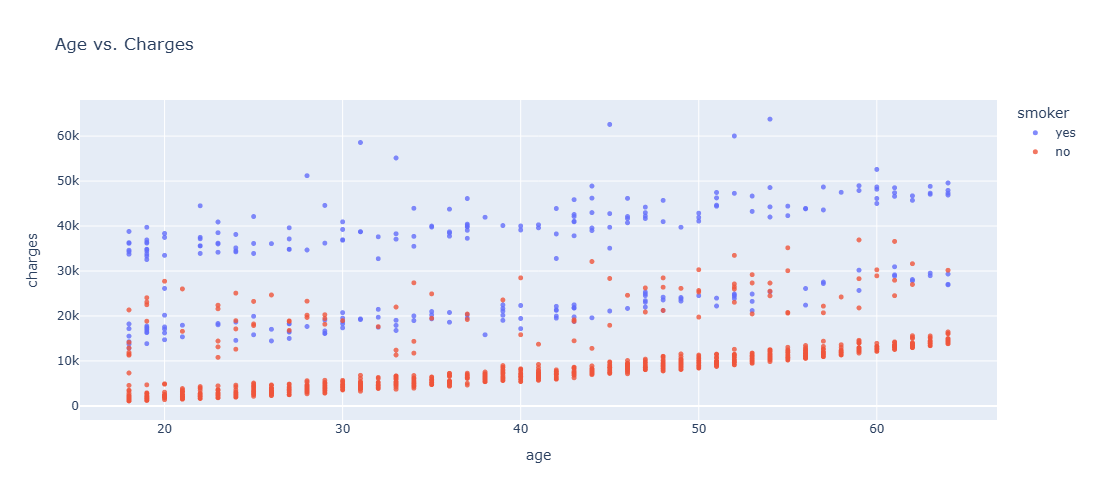

In [22]:
fig = px.scatter(medical_df, 
                 x='age', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

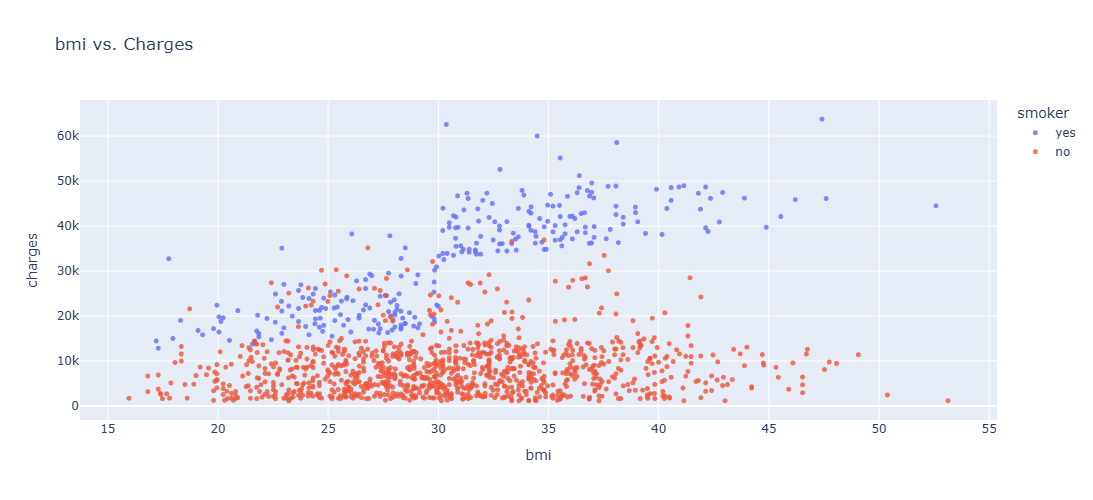

In [25]:
fig = px.scatter(medical_df, 
                 x='bmi', 
                 y='charges', 
                 color='smoker', 
                 opacity=0.8, 
                 hover_data=['sex'], 
                 title='bmi vs. Charges')
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

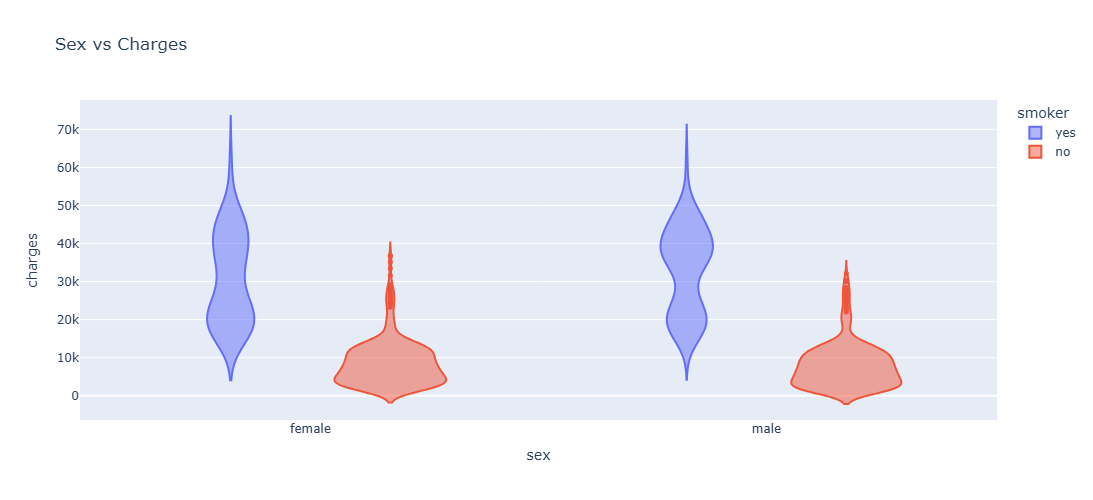

In [29]:
fig=px.violin(medical_df,x="sex",y="charges",color="smoker",title="Sex vs Charges")
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

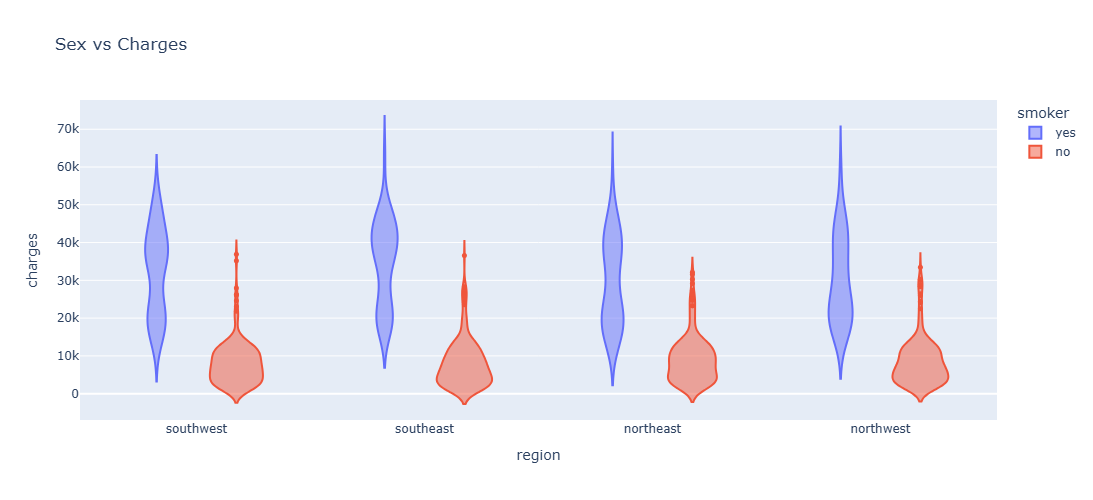

In [31]:
fig=px.violin(medical_df,x="region",y="charges",color="smoker",title="Sex vs Charges")
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

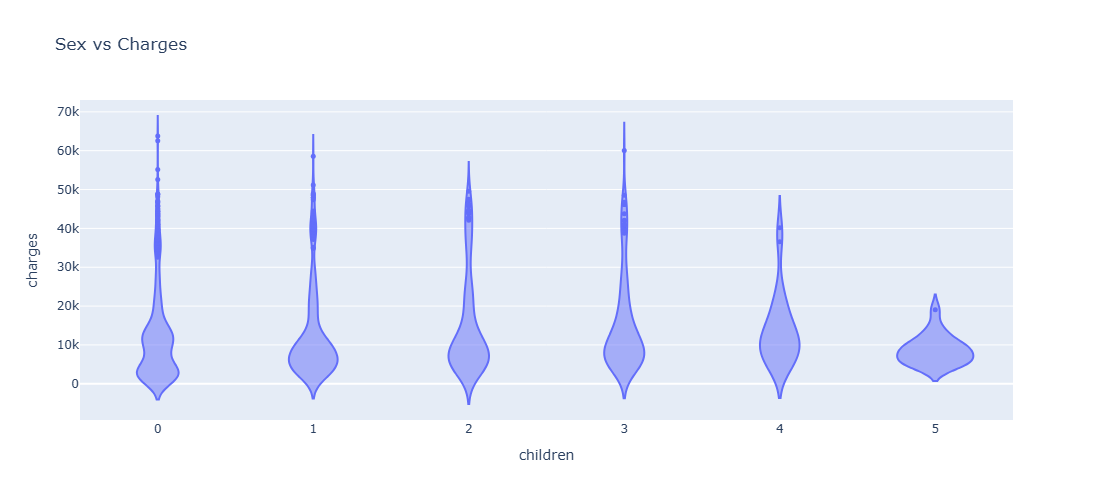

In [32]:
fig=px.violin(medical_df,x="children",y="charges",title="Sex vs Charges")
fig.update_traces(marker_size=5)
fig.update_layout(height=500)
fig.show()

In [34]:
df_numeric = medical_df.select_dtypes(include='number')
correleation=df_numeric.corr()

In [36]:
print(correleation)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
model=LinearRegression()

In [50]:
y=df.iloc[:,-1]


### Categorising Smoker

In [77]:
smk_map={'yes':1,'no':0}
medical_df['smoker_code']=medical_df['smoker'].map(smk_map)

In [78]:
medical_df


,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [79]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984767)

### categorising sex

In [80]:
sex_code={'male':0,"female":1}
medical_df['sex_code']=medical_df['sex'].map(sex_code)

In [81]:
medical_df.charges.corr(medical_df['sex_code'])

np.float64(-0.057292062202025366)

### Categorising Region

In [85]:
from sklearn import preprocessing

In [90]:
enc=preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [91]:
one_hot=enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [92]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']]=one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0.0,0.0,0.0,1.0


In [94]:
df_reg=medical_df.copy(True)

In [96]:
regx=df_reg[['age','bmi','children','smoker_code','northeast','northwest','southeast','southwest']]
regy=df_reg[['charges']]


In [105]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42
)

scaler=StandardScaler()
scaler.fit(medical_df[['age','bmi','children']])
scaler.mean_

scaler_input=scaler.transform(medical_df[['age','bmi','children']])
scaler_input

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))